In [1]:
# ==========================================
# InternCircle - Task 4
# First Machine Learning Classifier
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load Titanic dataset using Seaborn
df = sns.load_dataset("titanic")

print("Dataset Loaded Successfully!")
print("Dataset Shape:", df.shape)

display(df.head())

Dataset Loaded Successfully!
Dataset Shape: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [2]:
# ==========================================
# STEP 3 - Data Preprocessing
# ==========================================

# Select useful features
features = [
    "pclass",
    "sex",
    "age",
    "sibsp",
    "parch",
    "fare",
    "embarked"
]

target = "survived"

data = df[features + [target]].copy()

# Handle missing values
data["age"] = data["age"].fillna(data["age"].median())
data["fare"] = data["fare"].fillna(data["fare"].median())
data["embarked"] = data["embarked"].fillna(data["embarked"].mode()[0])

# Convert categorical columns into numbers
data = pd.get_dummies(
    data,
    columns=["sex", "embarked"],
    drop_first=True
)

# Separate input and output
X = data.drop("survived", axis=1)
y = data["survived"]

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Data Preprocessing Completed!")
print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Data Preprocessing Completed!
Training Data: (712, 8)
Testing Data: (179, 8)


In [6]:
# STEP 4 - Preprocessing and Train/Test Split

import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split

# Load dataset
df = sns.load_dataset("titanic")

# Select features
features = [
    "pclass",
    "sex",
    "age",
    "sibsp",
    "parch",
    "fare",
    "embarked"
]

data = df[features + ["survived"]].copy()

# Handle missing values
data["age"] = data["age"].fillna(data["age"].median())
data["fare"] = data["fare"].fillna(data["fare"].median())
data["embarked"] = data["embarked"].fillna(data["embarked"].mode()[0])

# Convert categorical columns
data = pd.get_dummies(
    data,
    columns=["sex", "embarked"],
    drop_first=True
)

# Input and output
X = data.drop("survived", axis=1)
y = data["survived"]

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Data Preprocessing Completed!")
print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Data Preprocessing Completed!
Training Data: (712, 8)
Testing Data: (179, 8)


In [7]:
# ==========================================
# STEP 5 - Train Decision Tree Model
# ==========================================

from sklearn.tree import DecisionTreeClassifier

# Create model
model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

# Train the model
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

print("Decision Tree Model Trained Successfully!")

Decision Tree Model Trained Successfully!


Model Accuracy: 76.54 %

Confusion Matrix:
[[97 13]
 [29 40]]


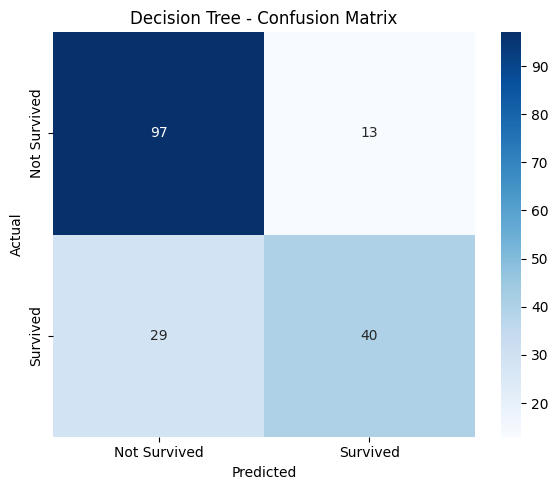


Classification Report:
              precision    recall  f1-score   support

Not Survived       0.77      0.88      0.82       110
    Survived       0.75      0.58      0.66        69

    accuracy                           0.77       179
   macro avg       0.76      0.73      0.74       179
weighted avg       0.76      0.77      0.76       179



In [8]:
# ==========================================
# STEP 6 - Model Evaluation
# ==========================================

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", round(accuracy * 100, 2), "%")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

# Display Confusion Matrix
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Survived", "Survived"],
    yticklabels=["Not Survived", "Survived"]
)

plt.title("Decision Tree - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# Classification Report
print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Not Survived", "Survived"]
    )
)

FEATURE IMPORTANCE


,0
sex_male,0.530655
pclass,0.180404
age,0.129043
fare,0.113752
embarked_S,0.034252
sibsp,0.011150
parch,0.000745
embarked_Q,0.000000


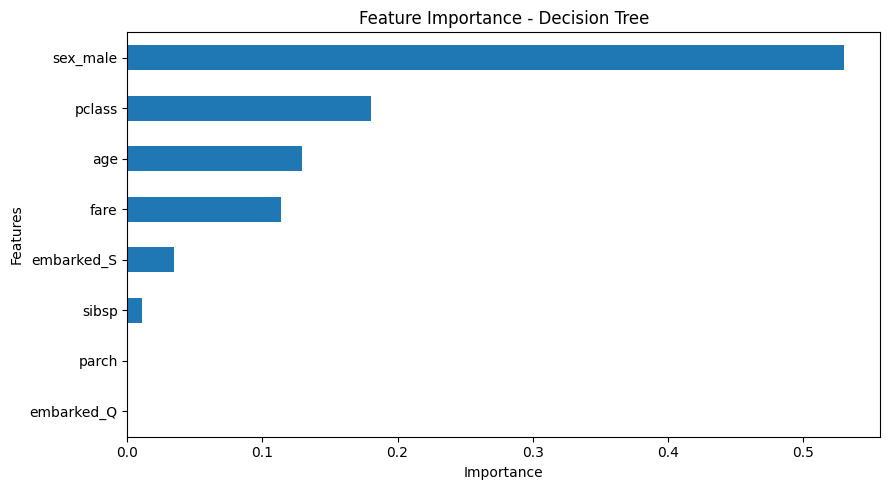


Task 4 Machine Learning Classification Completed Successfully!


In [9]:
# ==========================================
# STEP 7 - Feature Importance
# ==========================================

import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("FEATURE IMPORTANCE")
display(feature_importance)

# Feature Importance Graph
plt.figure(figsize=(9, 5))

feature_importance.sort_values().plot(kind="barh")

plt.title("Feature Importance - Decision Tree")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

print("\nTask 4 Machine Learning Classification Completed Successfully!")